---

<h1 style="color: #67EBFA; text-align: center;">Prueba Escrita – Arroyo Auz Christian Xavier</h1>
<h1 style="color: #67EBFA; text-align: center;">Laboratorio de Ciencia de Datos</h1>
<h1 style="color: #67EBFA; text-align: center;">Proceso de Selección de un Técnico de Investigación</h1>
<h1 style="color: #67EBFA; text-align: center;">Procesamiento y Análisis de Datos</h1>

## Objetivos
El objetivo de esta evaluación es analizar la capacidad del postulante para desarrollar un flujo completo de trabajo en ciencia de datos, desde el procesamiento de datos hasta el despliegue de un modelo como servicio.

Se evaluarán competencias en:
* Procesamiento y análisis de datos
* Modelado de Machine Learning
* Desarrollo de software
* Despliegue de servicios (API)
* Documentación y reproducibilidad

---

<h1 style="color: #9BFBE1; text-align: center;"><strong>EJECUCIÓN DE LA PRUEBA</strong></h1>

## DataSet a Utilizar (real_state_ecuador_dataset.csv)

Este conjunto de datos proporciona una descripción general completa de las propiedades de alquiler en Ecuador. Contiene una gran cantidad de información sobre las propiedades, como sus títulos y ubicaciones, así como el número de dormitorios, baños y garajes que contienen. Además, también incluye puntos de datos valiosos, como el tamaño del área, para ayudar a tomar decisiones informadas para quienes buscan alquilar o arrendar propiedades dentro del país. Los datos se pueden utilizar por diversas razones, como analizar tendencias en propiedades ofrecidas en alquiler y buscar diferencias de precios entre regiones o localidades.

Puedes descargar este dataset desde el siguiente [enlace](https://github.com/ivan-carrera/adalab-persel/blob/main/data/archive.zip).

## Descripción de las Variables del DataSet

A continuación se describe cada una de las columnas presentes en el dataset de propiedades en alquiler en Ecuador:

### 1. **Titulo**
- **Tipo:** Texto (string)
- **Descripción:** Contiene el título o descripción breve de la publicación del inmueble. Incluye características como el tipo de propiedad (departamento, casa, suite, local comercial, etc.), ubicación general, y en muchos casos, palabras clave como "oportunidad", "amoblado", o "estreno".
- **Ejemplo:** `"Hermoso departamento de arriendo sector iñaquito"`

### 2. **Precio**
- **Tipo:** Numérico (entero o decimal)
- **Descripción:** Indica el valor mensual del alquiler en dólares estadounidenses (USD). En algunos casos, puede incluir valores atípicos que corresponden a ventas o terrenos.
- **Ejemplo:** `500`, `375`, `650`

### 3. **Provincia**
- **Tipo:** Texto (string)
- **Descripción:** Provincia de Ecuador donde se encuentra el inmueble. La mayoría de los registros corresponden a **Pichincha**, aunque también aparecen otras como Guayas, Manabí, Imbabura, etc.
- **Ejemplo:** `"Pichincha"`, `"Guayas"`, `"Manabí"`

### 4. **Lugar**
- **Tipo:** Texto (string)
- **Descripción:** Descripción detallada de la ubicación del inmueble. Incluye provincia, ciudad, parroquia, sector, direcciones específicas y, en ocasiones, referencias geográficas o comerciales.
- **Ejemplo:** `"Pichincha, Iñaquito, Quito, Ecuador"`

### 5. **Num. dormitorios**
- **Tipo:** Numérico (entero) o `NaN`
- **Descripción:** Número de habitaciones o dormitorios que tiene la propiedad. Puede ser `NaN` en propiedades comerciales, terrenos, oficinas o locales sin dormitorios.
- **Ejemplo:** `2`, `3`, `1`, `NaN`

### 6. **Num. banos**
- **Tipo:** Numérico (entero o decimal) o `NaN`
- **Descripción:** Número de baños que tiene la propiedad. En algunos casos puede incluir medios baños (ej. `2.5`). Puede ser `NaN` si no aplica o no se especifica.
- **Ejemplo:** `2`, `1`, `3`, `NaN`, `2.5`

### 7. **Area**
- **Tipo:** Numérico (entero o decimal) o `NaN`
- **Descripción:** Superficie total del inmueble en metros cuadrados (m²). Puede incluir áreas construidas o del terreno. En algunos registros aparece como `NaN` si no se especifica.
- **Ejemplo:** `95`, `240`, `90`, `NaN`

### 8. **Num. garages**
- **Tipo:** Numérico (entero) o `NaN`
- **Descripción:** Número de espacios de estacionamiento o garajes disponibles en la propiedad. Puede ser `0` o `NaN` si no tiene o no se especifica.
- **Ejemplo:** `1`, `2`, `0`, `NaN`

### Resumen general del dataset

- **Enfoque:** Publicaciones de alquiler de inmuebles en Ecuador, principalmente en la provincia de Pichincha (Quito y sus alrededores).
- **Tipos de propiedades:** Departamentos, casas, suites, locales comerciales, oficinas, bodegas, terrenos, entre otros.
- **Variables clave:** Precio, ubicación, número de habitaciones, baños, área y garajes.
- **Datos faltantes:** Algunas variables como `Num. dormitorios`, `Num. banos`, `Area` y `Num. garages` presentan valores `NaN`, especialmente en propiedades no residenciales.

## Instalación de Librerías

```python
# Instalación de librerías necesarias para el análisis de datos
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install scipy
!pip install numpy

## Importar Librerías

In [1]:
# Nota: warnings y re son librerías estándar de Python, no requieren instalación
import matplotlib.pyplot as plt        # Creación de gráficos y visualizaciones personalizadas
from scipy import stats                # Funciones estadísticas y pruebas de hipótesis
import seaborn as sns                  # Visualización estadística avanzada (basada en matplotlib)
import pandas as pd                    # Manipulación y análisis de datos (DataFrames, lectura CSV)
import numpy as np                     # Operaciones numéricas y arrays multidimensionales
import warnings                        # Control de advertencias durante la ejecución
import re                              # Expresiones regulares para limpieza y extracción de texto
import os                              # Manejar rutas de archivos de forma independiente del sistema operativo

## Carga del DataSet

In [2]:
# Configuración de visualización
plt.style.use('seaborn-v0_8')                  # Configuración de estilo para gráficos
sns.set_palette("husl")                        # Establece paleta de colores vibrantes y uniformes
pd.set_option('display.max_columns', None)     # Muestra TODAS las columnas de DataFrames sin truncar

# Cargar el dataset
df = pd.read_csv('../data/real_state_ecuador_dataset.csv')
df.head(10)

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Hermoso departamento de arriendo sector iñaquito,500,Pichincha,"Pichincha, Iñaquito, Quito, Ecuador",2,2.0,95.0,1.0
1,Hermosa suite de arriendo sector iñaquito,375,Pichincha,"Pichincha, Quito, Ecuador",1,1.0,65.0,1.0
2,Hermoso departamento de oportunidad de arriend...,650,Pichincha,"Pichincha, Av. República de El Salvador, Quito...",2,2.0,120.0,1.0
3,Hermoso departamento de arriendo de 240 metros...,560,Pichincha,"Pichincha, Albert Einstein, Quito, Ecuador",3,3.0,240.0,2.0
4,Hermoso departamento de arriendo de oportunida...,580,Pichincha,"Pichincha, Urbanización El Condado, Calle C, Q...",3,4.0,128.0,2.0
5,Hermosa suite de arriendo de oportunidad secto...,460,Pichincha,"Pichincha, Quito Tenis, Quito, Ecuador",1,1.0,58.0,1.0
6,Hermoso departamento en renta sector Quito Tenis,435,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",2,2.0,98.0,1.0
7,Hermoso departamento de arriendo en la Urb. El...,750,Pichincha,"Pichincha, VGW2+Q5J, Quito 170134, Ecuador",3,3.0,190.0,1.0
8,Hermosa suite amoblada de arriendo sector Quit...,570,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",1,1.0,61.0,1.0
9,Hermoso departamento en renta/venta sector Qui...,1800,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",4,3.0,380.0,3.0


## Limpieza y Normalización

In [3]:
# Función para extraer información relevante de Lugar
def extract_location_info(lugar_str):
    """
    Extrae ciudad y sector de la columna Lugar
    Ejemplo: "Pichincha, Iñaquito, Quito, Ecuador" -> {"ciudad": "Quito", "sector": "Iñaquito"}
    """
    # Si el valor es nulo, devolvemos una Serie con None
    if pd.isna(lugar_str):
        return pd.Series({'ciudad': None, 'sector': None})
    
    # Dividimos la cadena por comas y limpiamos espacios
    partes = lugar_str.split(',')
    partes = [p.strip() for p in partes]
    
    # Inicializamos las variables a None
    ciudad_encontrada = None  # <--- Variable inicializada aquí
    sector = None
    
    # Lista de ciudades conocidas para buscar en el texto
    ciudades_conocidas = ['Quito', 'Guayaquil', 'Cuenca', 'Sangolquí', 'Cumbayá', 
                          'Tumbaco', 'Machala', 'Manta', 'Babahoyo', 'Latacunga']
    
    # Buscamos si alguna parte coincide con una ciudad conocida
    for parte in partes:
        for ciudad in ciudades_conocidas:
            if ciudad.lower() in parte.lower():
                ciudad_encontrada = ciudad
                break   # Rompemos el bucle interno
        if ciudad_encontrada:  # Si ya encontramos ciudad, rompemos el bucle externo
            break
    
    # Si encontramos una ciudad, el sector suele estar justo antes
    if ciudad_encontrada:
        # Obtenemos el índice de la parte que contiene la ciudad
        for i, parte in enumerate(partes):
            if ciudad_encontrada.lower() in parte.lower():
                idx_ciudad = i
                break
        
        # Si la ciudad no es el primer elemento, el anterior es el sector
        if idx_ciudad > 0:
            sector = partes[idx_ciudad - 1]
    
    # Devolvemos los resultados como una Serie de pandas
    return pd.Series({'ciudad': ciudad_encontrada, 'sector': sector})

In [4]:
# Aplicar la función extract_location_info a cada valor de la columna 'Lugar'
# La función devuelve una Serie con dos valores: 'ciudad' y 'sector'
# Luego asignamos esos dos valores a dos nuevas columnas en el DataFrame: 'ciudad' y 'sector'
df[['ciudad', 'sector']] = df['Lugar'].apply(extract_location_info)

# Normalizar nombres de provincias:
# .str.strip()  -> Elimina espacios en blanco al inicio y final de cada texto
# .str.title()  -> Convierte la primera letra de cada palabra a mayúscula y el resto a minúsculas
# Ejemplo: "pICHINCHA" -> "Pichincha"
df['Provincia'] = df['Provincia'].str.strip().str.title()
df.head(10)

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages,ciudad,sector
0,Hermoso departamento de arriendo sector iñaquito,500,Pichincha,"Pichincha, Iñaquito, Quito, Ecuador",2,2.0,95.0,1.0,Quito,Pichincha
1,Hermosa suite de arriendo sector iñaquito,375,Pichincha,"Pichincha, Quito, Ecuador",1,1.0,65.0,1.0,Quito,Pichincha
2,Hermoso departamento de oportunidad de arriend...,650,Pichincha,"Pichincha, Av. República de El Salvador, Quito...",2,2.0,120.0,1.0,Quito,Av. República de El Salvador
3,Hermoso departamento de arriendo de 240 metros...,560,Pichincha,"Pichincha, Albert Einstein, Quito, Ecuador",3,3.0,240.0,2.0,Quito,Albert Einstein
4,Hermoso departamento de arriendo de oportunida...,580,Pichincha,"Pichincha, Urbanización El Condado, Calle C, Q...",3,4.0,128.0,2.0,Quito,Calle C
5,Hermosa suite de arriendo de oportunidad secto...,460,Pichincha,"Pichincha, Quito Tenis, Quito, Ecuador",1,1.0,58.0,1.0,Quito,Pichincha
6,Hermoso departamento en renta sector Quito Tenis,435,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",2,2.0,98.0,1.0,Quito,Pichincha
7,Hermoso departamento de arriendo en la Urb. El...,750,Pichincha,"Pichincha, VGW2+Q5J, Quito 170134, Ecuador",3,3.0,190.0,1.0,Quito,VGW2+Q5J
8,Hermosa suite amoblada de arriendo sector Quit...,570,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",1,1.0,61.0,1.0,Quito,Pichincha
9,Hermoso departamento en renta/venta sector Qui...,1800,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",4,3.0,380.0,3.0,Quito,Pichincha


## Manejo de Valores Faltantes

In [5]:
# Análisis de valores faltantes
# .isnull().sum() cuenta cuántos valores nulos hay en cada columna
missing_values = df.isnull().sum()

# Calculamos el porcentaje de valores faltantes
missing_percentage = (missing_values / len(df)) * 100

# Creamos un DataFrame con la información de valores faltantes
missing_df = pd.DataFrame({'Missing': missing_values, 'Percentage': missing_percentage})

# Mostramos solo las columnas que tienen al menos un valor faltante
# Ordenamos de mayor a menor cantidad de valores faltantes
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

                  Missing  Percentage
Num. garages          152        30.4
Num. dormitorios      140        28.0
Num. banos             97        19.4
ciudad                 51        10.2
sector                 51        10.2
Area                   18         3.6


In [6]:
# Estrategias de imputación (rellenar valores faltantes)
# Para columnas numéricas: usar la mediana
warnings.simplefilter("ignore")
# Lista de columnas numéricas (¡verifica que los nombres coincidan exactamente con el CSV!)
numeric_cols = ['Num. dormitorios', 'Num. banos', 'Area', 'Num. garages']

# Procesamos cada columna numérica
for col in numeric_cols:
    # Convertimos la columna a tipo numérico (si hay errores, los convierte a NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Rellenamos los valores NaN con la mediana de la columna
    # fillna() reemplaza NaN con el valor especificado
    # inplace=True modifica el DataFrame directamente
    df[col].fillna(df[col].median(), inplace=True)

# Para categóricos: crear categoría 'Desconocido'
df['ciudad'].fillna('Desconocido', inplace=True)
df['sector'].fillna('Desconocido', inplace=True)

# Verificar que no queden nulos
print(df.isnull().sum())

Titulo              0
Precio              0
Provincia           0
Lugar               0
Num. dormitorios    0
Num. banos          0
Area                0
Num. garages        0
ciudad              0
sector              0
dtype: int64


## Análisis Descriptivo

In [7]:
# 1. Total de propiedades
total_propiedades = len(df)
print(f"Total de propiedades: {total_propiedades}")

# 2. Por provincia
prop_por_provincia = df['Provincia'].value_counts()
print("\nPropiedades por provincia:")
print(prop_por_provincia)

# 3. Por lugar (ciudad)
prop_por_ciudad = df['ciudad'].value_counts().head(10)
print("\nTop 10 ciudades:")
print(prop_por_ciudad)

# 4. Mediana y promedio de precio
precio_mediana_general = df['Precio'].median()
precio_promedio_general = df['Precio'].mean()
print(f"\nPrecio General - Mediana: ${precio_mediana_general:.2f}, Promedio: ${precio_promedio_general:.2f}")

# 5. Por ciudad
precio_por_ciudad = df.groupby('ciudad')['Precio'].agg(['median', 'mean', 'count']).round(2)
precio_por_ciudad = precio_por_ciudad[precio_por_ciudad['count'] >= 5].sort_values('median', ascending=False)
print("\nPrecio por ciudad (mínimo 5 propiedades):")
print(precio_por_ciudad)

Total de propiedades: 500

Propiedades por provincia:
Provincia
Pichincha      443
Guayas          34
Manabí           9
Esmeraldas       4
Los Rios         3
Cotopaxi         2
El Oro           2
Orellana         1
Imbabura         1
Santa Elena      1
Name: count, dtype: int64

Top 10 ciudades:
ciudad
Quito          376
Desconocido     51
Sangolquí       29
Guayaquil       27
Cumbayá          7
Babahoyo         3
Machala          3
Latacunga        2
Tumbaco          1
Manta            1
Name: count, dtype: int64

Precio General - Mediana: $500.00, Promedio: $833.70

Precio por ciudad (mínimo 5 propiedades):
             median     mean  count
ciudad                             
Cumbayá       950.0  1325.71      7
Desconocido   700.0  1727.69     51
Sangolquí     585.0   583.62     29
Guayaquil     500.0   518.48     27
Quito         500.0   735.04    376



--- Gráfico Área vs Precio ---
Total de propiedades originales: 500
Propiedades después del filtro (Area < 1000m² y Precio < $10000): 490
Propiedades excluidas del gráfico: 10


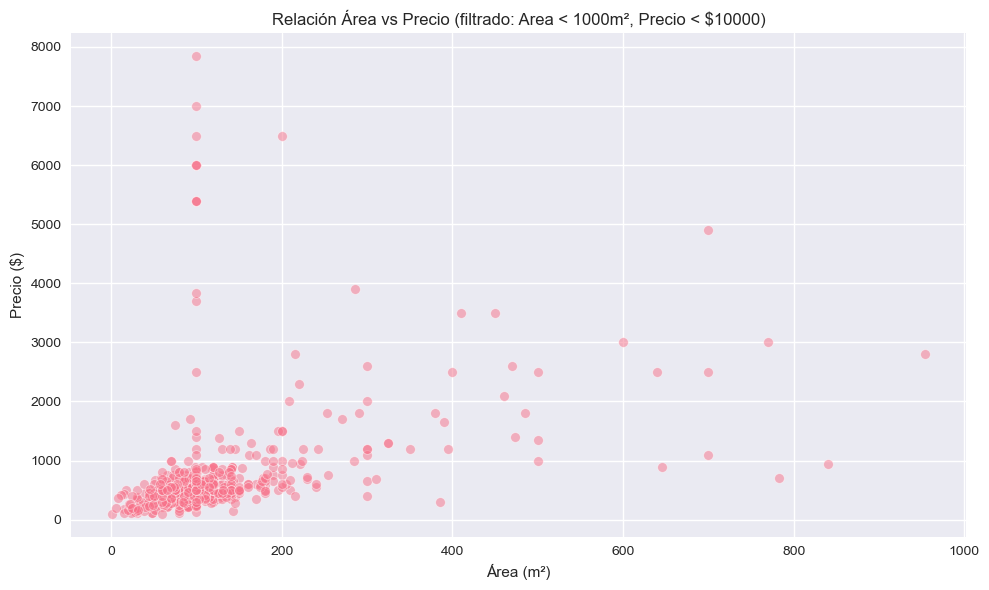

Correlación Área-Precio (con datos filtrados): 0.359
Correlación Área-Precio (con todos los datos): -0.019


In [8]:
# 6. Relación Área vs Precio
# Crear un DataFrame filtrado para eliminar valores extremos
# Esto mejora la visualización de la gráfica
df_filtrado = df[(df['Area'] < 1000) & (df['Precio'] < 10000)]

# Mostrar cuántos datos estamos usando vs cuántos filtramos
print(f"\n--- Gráfico Área vs Precio ---")
print(f"Total de propiedades originales: {len(df)}")
print(f"Propiedades después del filtro (Area < 1000m² y Precio < $10000): {len(df_filtrado)}")
print(f"Propiedades excluidas del gráfico: {len(df) - len(df_filtrado)}")

# Verificamos que exista el directorio 'plots' antes de guardar
os.makedirs('../plots', exist_ok=True)

# Crear la gráfica con los datos filtrados
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtrado, x='Area', y='Precio', alpha=0.5)
plt.title('Relación Área vs Precio (filtrado: Area < 1000m², Precio < $10000)')
plt.xlabel('Área (m²)')
plt.ylabel('Precio ($)')
plt.tight_layout()
plt.savefig('../plots/area_vs_precio_filtrado.png', dpi=100, bbox_inches='tight')
plt.show()

# Calcular la correlación con los datos filtrados
correlacion_filtrada = df_filtrado['Area'].corr(df_filtrado['Precio'])
print(f"Correlación Área-Precio (con datos filtrados): {correlacion_filtrada:.3f}")

# Opcional: Calcular también la correlación con todos los datos para comparar
correlacion_completa = df['Area'].corr(df['Precio'])
print(f"Correlación Área-Precio (con todos los datos): {correlacion_completa:.3f}")

## Análisis de Premium por Habitación Adicional


ANÁLISIS DE PRECIOS POR NÚMERO DE HABITACIONES
              mean  median  count    min     max
rango_hab                                       
1 hab       851.15   500.0     78  120.0  6000.0
2 hab       488.44   470.0     97  100.0  1700.0
3 hab       863.58   500.0    284    9.0  8000.0
4 hab      1175.00   825.0     28  350.0  3500.0
5 hab      1300.00  1000.0      7  350.0  3000.0
6-10 hab   1365.00   900.0      5  125.0  3000.0
11+ hab        NaN     NaN      0    NaN     NaN

PREMIUM POR HABITACIÓN ADICIONAL (basado en mediana)
     Comparación  Diferencia ($)  Incremento (%) Muestras
   1 hab → 2 hab           -30.0           -6.00  78 → 97
   2 hab → 3 hab            30.0            6.38 97 → 284
   3 hab → 4 hab           325.0           65.00 284 → 28
   4 hab → 5 hab           175.0           21.21   28 → 7
5 hab → 6-10 hab          -100.0          -10.00    7 → 5


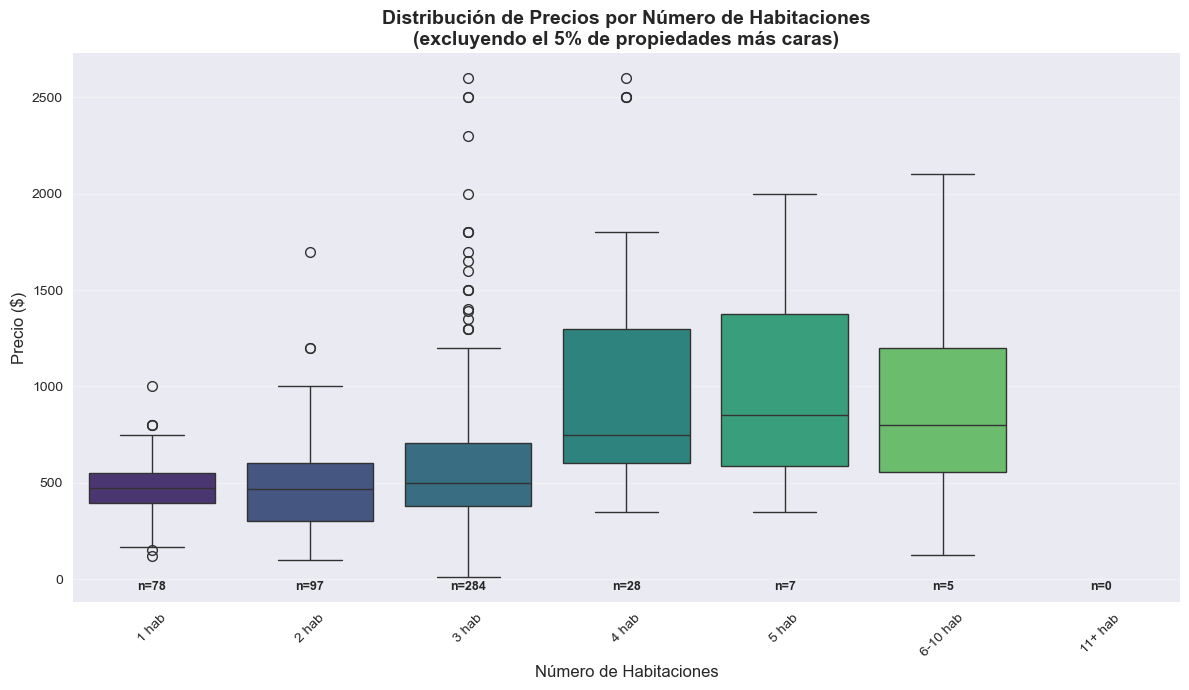


PRECIO POR METRO CUADRADO SEGÚN HABITACIONES
            mean  median  count
rango_hab                      
1 hab      11.50    7.54     78
2 hab       6.29    5.00     97
3 hab       7.06    4.61    284
4 hab       3.95    3.47     28
5 hab       4.35    3.89      7
6-10 hab    2.82    3.90      5
11+ hab      NaN     NaN      0


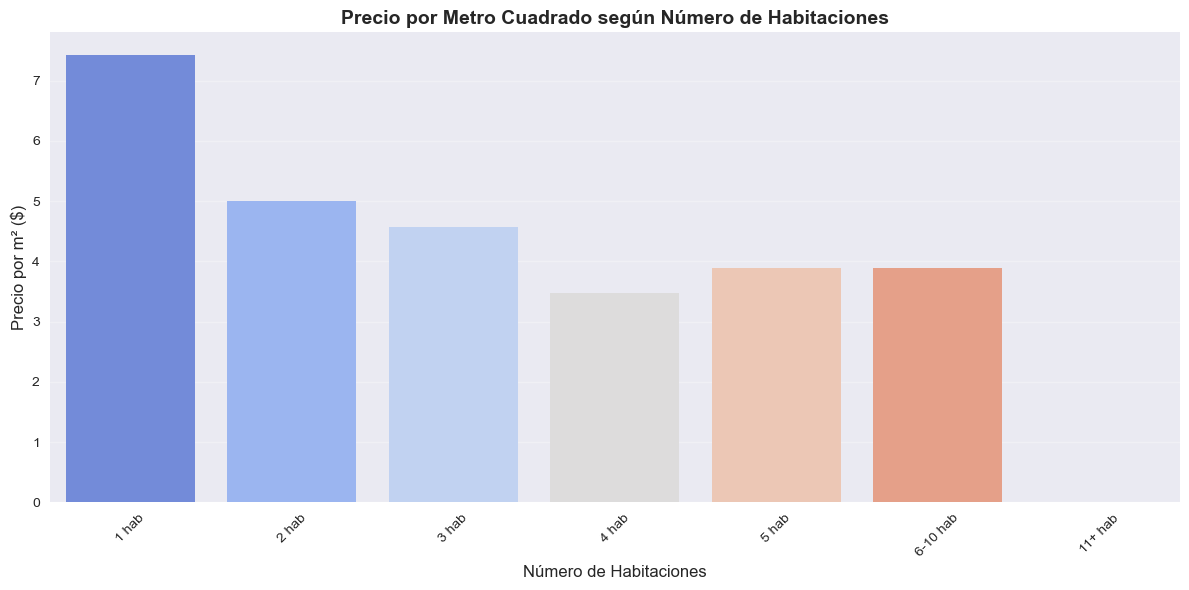

In [9]:
# Crear rangos de habitaciones (más precisos)
df['rango_hab'] = pd.cut(df['Num. dormitorios'], 
                         bins=[0, 1, 2, 3, 4, 5, 10, 20], 
                         labels=['1 hab', '2 hab', '3 hab', '4 hab', '5 hab', '6-10 hab', '11+ hab'])

# Calcular estadísticas por rango de habitaciones
precio_por_hab = df.groupby('rango_hab')['Precio'].agg(['mean', 'median', 'count', 'min', 'max']).round(2)
print("\n" + "="*60)
print("ANÁLISIS DE PRECIOS POR NÚMERO DE HABITACIONES")
print("="*60)
print(precio_por_hab)

# Filtrar rangos con suficientes datos para el análisis de premium (mínimo 3 propiedades)
rangos_validos = precio_por_hab[precio_por_hab['count'] >= 3].index.tolist()

# Calcular premium por habitación adicional
premiums = []
for i in range(len(rangos_validos) - 1):
    hab_actual = rangos_validos[i]
    hab_siguiente = rangos_validos[i + 1]
    
    # Usar mediana en lugar de media para evitar distorsión por outliers
    precio_actual = precio_por_hab.loc[hab_actual, 'median']
    precio_siguiente = precio_por_hab.loc[hab_siguiente, 'median']
    
    if precio_actual > 0:  # Evitar división por cero
        diferencia = precio_siguiente - precio_actual
        porcentaje = (diferencia / precio_actual) * 100
        
        premiums.append({
            'Comparación': f"{hab_actual} → {hab_siguiente}",
            'Diferencia ($)': round(diferencia, 2),
            'Incremento (%)': round(porcentaje, 2),
            'Muestras': f"{precio_por_hab.loc[hab_actual, 'count']} → {precio_por_hab.loc[hab_siguiente, 'count']}"
        })

if premiums:
    premiums_df = pd.DataFrame(premiums)
    print("\n" + "="*60)
    print("PREMIUM POR HABITACIÓN ADICIONAL (basado en mediana)")
    print("="*60)
    print(premiums_df.to_string(index=False))
else:
    print("\nNo hay suficientes datos para calcular premiums.")

# Visualización mejorada
plt.figure(figsize=(12, 7))

# Crear boxplot con los datos filtrados (excluir outliers extremos para mejor visualización)
df_filtrado_hab = df[df['Precio'] < df['Precio'].quantile(0.95)]  # Excluir top 5% de precios

sns.boxplot(data=df_filtrado_hab, x='rango_hab', y='Precio', palette='viridis')
plt.title('Distribución de Precios por Número de Habitaciones\n(excluyendo el 5% de propiedades más caras)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Número de Habitaciones', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Añadir etiquetas con el número de muestras por categoría
for i, rango in enumerate(precio_por_hab.index):
    count = precio_por_hab.loc[rango, 'count']
    plt.text(i, plt.ylim()[0] + 50, f'n={count}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/precio_por_habitaciones_mejorado.png', dpi=100, bbox_inches='tight')
plt.show()

# Análisis adicional: precio por metro cuadrado según habitaciones
print("\n" + "="*60)
print("PRECIO POR METRO CUADRADO SEGÚN HABITACIONES")
print("="*60)

# Calcular precio por m²
df['precio_m2'] = df['Precio'] / df['Area']
df['precio_m2'] = df['precio_m2'].replace([float('inf'), -float('inf')], float('nan'))  # Eliminar infinitos

# Agrupar por rango de habitaciones
precio_m2_por_hab = df.groupby('rango_hab')['precio_m2'].agg(['mean', 'median', 'count']).round(2)
print(precio_m2_por_hab)

# Visualizar precio por m²
plt.figure(figsize=(12, 6))
sns.barplot(data=df[df['precio_m2'] < 50], x='rango_hab', y='precio_m2', 
            estimator='median', errorbar=None, palette='coolwarm')
plt.title('Precio por Metro Cuadrado según Número de Habitaciones', fontsize=14, fontweight='bold')
plt.xlabel('Número de Habitaciones', fontsize=12)
plt.ylabel('Precio por m² ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/precio_m2_por_habitaciones.png', dpi=100, bbox_inches='tight')
plt.show()

## Crear Columna Tipo de Precio por Lugar

In [10]:
# Calcular cuartiles por ciudad
def asignar_tipo_precio(grupo):
    q1 = grupo['Precio'].quantile(0.25)
    q3 = grupo['Precio'].quantile(0.75)
    
    def categorizar(precio):
        if precio < q1:
            return 'Económico'
        elif precio > q3:
            return 'Lujo'
        else:
            return 'Medio'
    
    return grupo['Precio'].apply(categorizar)

# Aplicar por ciudad (con al menos 5 propiedades)
ciudades_validas = df['ciudad'].value_counts()[df['ciudad'].value_counts() >= 5].index
df_valid = df[df['ciudad'].isin(ciudades_validas)].copy()

tipos = []
for ciudad in ciudades_validas:
    mask = df_valid['ciudad'] == ciudad
    df_valid.loc[mask, 'tipo_precio'] = asignar_tipo_precio(df_valid[mask])

# Para ciudades con pocos datos, usar cuartiles generales
q1_general = df['Precio'].quantile(0.25)
q3_general = df['Precio'].quantile(0.75)

def categorizar_general(precio):
    if precio < q1_general:
        return 'Económico'
    elif precio > q3_general:
        return 'Lujo'
    else:
        return 'Medio'
df['tipo_precio'] = df['Precio'].apply(categorizar_general)
df.loc[df_valid.index, 'tipo_precio'] = df_valid['tipo_precio']
df.head(10)

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages,ciudad,sector,rango_hab,precio_m2,tipo_precio
0,Hermoso departamento de arriendo sector iñaquito,500,Pichincha,"Pichincha, Iñaquito, Quito, Ecuador",2.0,2.0,95.0,1.0,Quito,Pichincha,2 hab,5.263158,Medio
1,Hermosa suite de arriendo sector iñaquito,375,Pichincha,"Pichincha, Quito, Ecuador",1.0,1.0,65.0,1.0,Quito,Pichincha,1 hab,5.769231,Económico
2,Hermoso departamento de oportunidad de arriend...,650,Pichincha,"Pichincha, Av. República de El Salvador, Quito...",2.0,2.0,120.0,1.0,Quito,Av. República de El Salvador,2 hab,5.416667,Medio
3,Hermoso departamento de arriendo de 240 metros...,560,Pichincha,"Pichincha, Albert Einstein, Quito, Ecuador",3.0,3.0,240.0,2.0,Quito,Albert Einstein,3 hab,2.333333,Medio
4,Hermoso departamento de arriendo de oportunida...,580,Pichincha,"Pichincha, Urbanización El Condado, Calle C, Q...",3.0,4.0,128.0,2.0,Quito,Calle C,3 hab,4.531250,Medio
5,Hermosa suite de arriendo de oportunidad secto...,460,Pichincha,"Pichincha, Quito Tenis, Quito, Ecuador",1.0,1.0,58.0,1.0,Quito,Pichincha,1 hab,7.931034,Medio
6,Hermoso departamento en renta sector Quito Tenis,435,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",2.0,2.0,98.0,1.0,Quito,Pichincha,2 hab,4.438776,Medio
7,Hermoso departamento de arriendo en la Urb. El...,750,Pichincha,"Pichincha, VGW2+Q5J, Quito 170134, Ecuador",3.0,3.0,190.0,1.0,Quito,VGW2+Q5J,3 hab,3.947368,Lujo
8,Hermosa suite amoblada de arriendo sector Quit...,570,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",1.0,1.0,61.0,1.0,Quito,Pichincha,1 hab,9.344262,Medio
9,Hermoso departamento en renta/venta sector Qui...,1800,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",4.0,3.0,380.0,3.0,Quito,Pichincha,4 hab,4.736842,Lujo


tipo_precio
Medio        259
Económico    122
Lujo         119
Name: count, dtype: int64


tipo_precio
Medio        51.8
Económico    24.4
Lujo         23.8
Name: proportion, dtype: float64


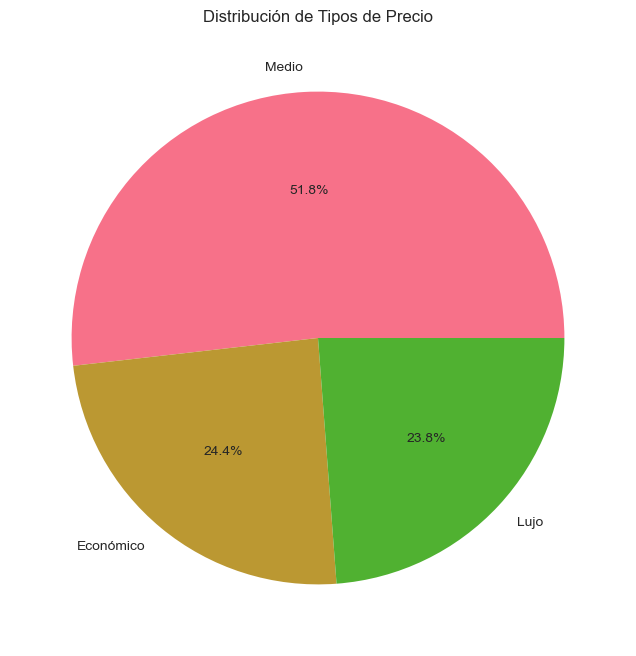

In [11]:
# Distribución de tipos
print(df['tipo_precio'].value_counts())
print("")
print("")
print(df['tipo_precio'].value_counts(normalize=True) * 100)

# Visualización
plt.figure(figsize=(8, 8))
df['tipo_precio'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución de Tipos de Precio')
plt.ylabel('')
plt.savefig('../plots/tipos_precio.png', dpi=100, bbox_inches='tight')
plt.show()

## Análisis Adicionales Relevantes


DISTRIBUCIÓN POR TIPO DE PROPIEDAD
tipo_propiedad
Departamento       210
Suite               59
Casa                55
Local Comercial     51
Oficina             51
Otro                47
Bodega              15
Terreno             12
Name: count, dtype: int64


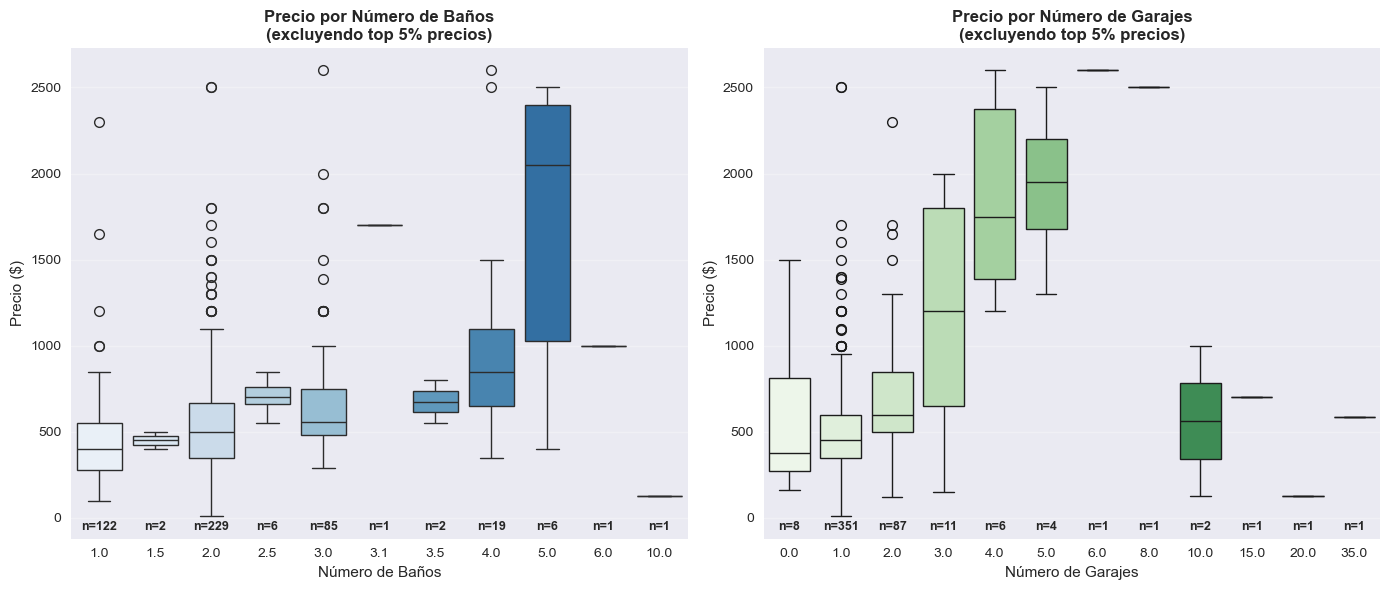


TOP 10 SECTORES MÁS CAROS (mínimo 3 propiedades)
                                       mean  median  count      std
sector_clean                                                       
Av. De Los Shyris                   3196.67  1200.0      3  4179.48
Calderón                            1983.33   600.0      3  2527.02
Desconocido                         1727.69   700.0     51  2199.36
Avenue 12 De Octubre                1280.00   750.0      3  1059.58
Veracruz & Avenida De La República   933.33   850.0      3   529.94
Av. República De El Salvador         816.67   900.0      3   144.34
Andalucia                            800.00   390.0      3   870.69
Av. 6 De Diciembre                   775.00   675.0      4   295.80
Conocoto                             770.00   940.0      3   347.71
La Pradera                           716.67   700.0      3   175.59


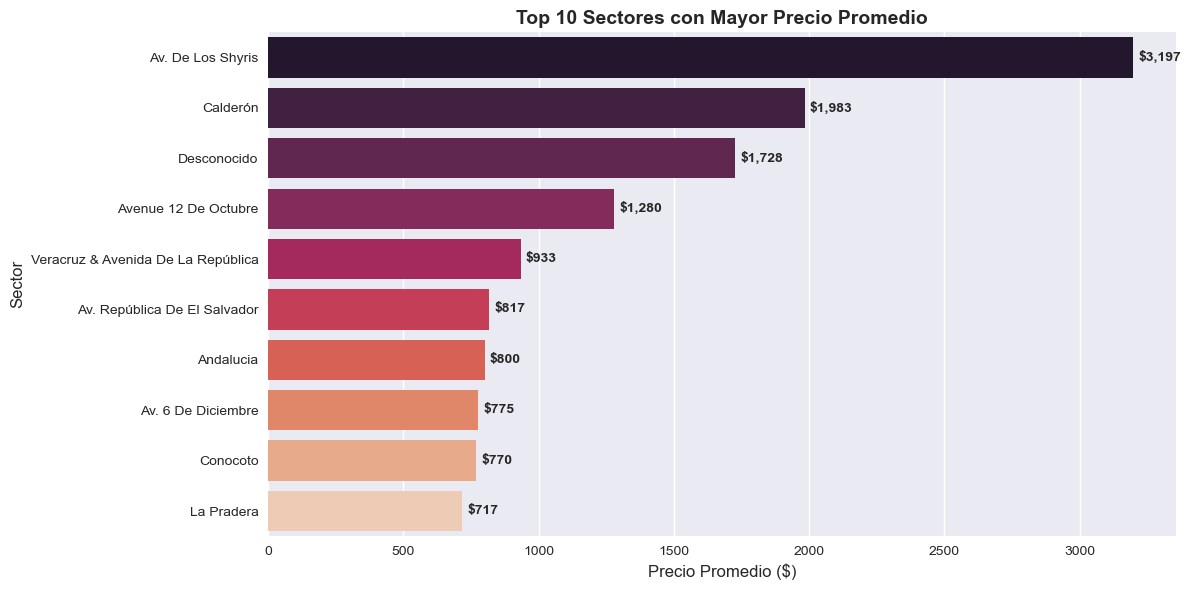

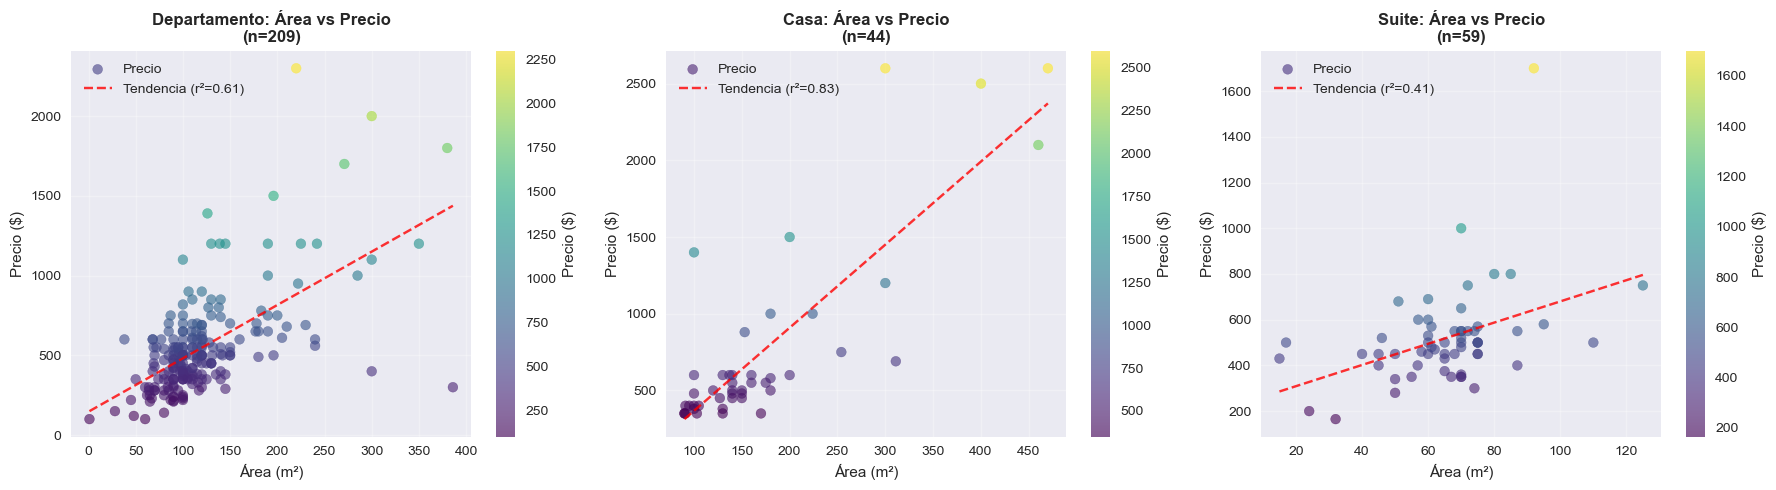


RESUMEN ESTADÍSTICO POR TIPO DE PROPIEDAD
                  Precio                               Area         \
                    mean  median  min   max count      mean median   
tipo_propiedad                                                       
Bodega           1534.27  1000.0  270  4500    15    481.33  324.0   
Casa             1146.18   600.0  350  6000    55    239.71  150.0   
Departamento      560.85   500.0  100  3000   210    126.92  105.0   
Local Comercial   914.12   600.0  120  8000    51    118.96   90.0   
Oficina           516.37   452.0  120  2000    51     74.25   58.0   
Otro             1648.72   700.0  115  9000    47    407.00  100.0   
Suite             518.31   500.0  165  1700    59     65.12   68.0   
Terreno          2666.17  1350.0    9  7000    12  17519.00  100.0   

                Num. dormitorios        Num. banos         
                            mean median       mean median  
tipo_propiedad                                             
Bodega

In [12]:
# =============================================================================
# ANÁLISIS DE PROPIEDADES INMOBILIARIAS - ECUADOR
# =============================================================================

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')  # Estilo más profesional
sns.set_palette("husl")  # Paleta de colores atractiva

# Crear directorio para guardar gráficos
os.makedirs('../plots', exist_ok=True)

# =============================================================================
# 1. INFERIR TIPO DE PROPIEDAD A PARTIR DEL TÍTULO (MEJORADO)
# =============================================================================

def inferir_tipo_propiedad(titulo):
    """
    Analiza el título de una propiedad para determinar su tipo.
    
    Args:
        titulo (str): Título descriptivo de la propiedad
        
    Returns:
        str: Tipo de propiedad inferido
    """
    if pd.isna(titulo) or not isinstance(titulo, str):
        return 'Desconocido'
    
    titulo_lower = titulo.lower().strip()
    
    # Mapeo de palabras clave a tipos de propiedad
    tipos = {
        'casa': 'Casa',
        'departamento': 'Departamento',
        'depto': 'Departamento',
        'suite': 'Suite',
        'local': 'Local Comercial',
        'oficina': 'Oficina',
        'consultorio': 'Oficina',  # Agrupamos consultorios con oficinas
        'bodega': 'Bodega',
        'galpón': 'Bodega',  # Sinónimo de bodega
        'galpon': 'Bodega',  # Versión sin tilde
        'terreno': 'Terreno',
        'lote': 'Terreno',  # Sinónimo de terreno
        'quinta': 'Casa',  # Propiedad rural
        'villa': 'Casa',
        'penthouse': 'Departamento',  # Tipo específico de departamento
        'loft': 'Suite',  # Tipo específico de suite
        'duplex': 'Departamento'  # Tipo de departamento
    }
    
    # Buscar coincidencias (priorizamos palabras más específicas)
    for palabra, tipo in tipos.items():
        # Usamos límites de palabra para evitar falsos positivos
        # Ej: "local" no debería coincidir con "localidad"
        if re.search(r'\b' + re.escape(palabra) + r'\b', titulo_lower):
            return tipo
    
    return 'Otro'

# Aplicar la función mejorada
df['tipo_propiedad'] = df['Titulo'].apply(inferir_tipo_propiedad)

# Mostrar distribución de tipos
print("\n" + "="*60)
print("DISTRIBUCIÓN POR TIPO DE PROPIEDAD")
print("="*60)
tipo_counts = df['tipo_propiedad'].value_counts()
print(tipo_counts)

# =============================================================================
# 2. RELACIÓN ENTRE BAÑOS Y PRECIO (MEJORADO)
# =============================================================================

# Filtrar valores extremos para mejor visualización
df_banos_filtrado = df[df['Precio'] < df['Precio'].quantile(0.95)]  # Excluir top 5% precios

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Precio por número de baños
sns.boxplot(data=df_banos_filtrado, x='Num. banos', y='Precio', ax=axes[0], palette='Blues')
axes[0].set_title('Precio por Número de Baños\n(excluyendo top 5% precios)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Baños', fontsize=11)
axes[0].set_ylabel('Precio ($)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Añadir conteo de muestras
for i, banos in enumerate(sorted(df_banos_filtrado['Num. banos'].unique())):
    count = df_banos_filtrado[df_banos_filtrado['Num. banos'] == banos].shape[0]
    axes[0].text(i, axes[0].get_ylim()[0] + 50, f'n={count}', 
                ha='center', fontsize=9, fontweight='bold')

# Gráfico 2: Precio por número de garajes
sns.boxplot(data=df_banos_filtrado, x='Num. garages', y='Precio', ax=axes[1], palette='Greens')
axes[1].set_title('Precio por Número de Garajes\n(excluyendo top 5% precios)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Garajes', fontsize=11)
axes[1].set_ylabel('Precio ($)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Añadir conteo de muestras
garajes_unicos = sorted([g for g in df_banos_filtrado['Num. garages'].unique() if pd.notna(g)])
for i, garaje in enumerate(garajes_unicos):
    count = df_banos_filtrado[df_banos_filtrado['Num. garages'] == garaje].shape[0]
    axes[1].text(i, axes[1].get_ylim()[0] + 50, f'n={count}', 
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/precio_banos_garages_mejorado.png', dpi=100, bbox_inches='tight')
plt.show()

# =============================================================================
# 3. TOP 10 SECTORES MÁS CAROS (MEJORADO)
# =============================================================================

# Limpiar sectores (eliminar espacios extras, capitalizar)
df['sector_clean'] = df['sector'].str.strip().str.title() if 'sector' in df.columns else None

# Calcular estadísticas por sector
top_sectores = df.groupby('sector_clean')['Precio'].agg(['mean', 'median', 'count', 'std']).round(2)
top_sectores = top_sectores[top_sectores['count'] >= 3].sort_values('mean', ascending=False).head(10)

print("\n" + "="*60)
print("TOP 10 SECTORES MÁS CAROS (mínimo 3 propiedades)")
print("="*60)
print(top_sectores.to_string())

# Visualización de sectores más caros
plt.figure(figsize=(12, 6))
top_10_plot = top_sectores.reset_index()
sns.barplot(data=top_10_plot, x='mean', y='sector_clean', palette='rocket')
plt.title('Top 10 Sectores con Mayor Precio Promedio', fontsize=14, fontweight='bold')
plt.xlabel('Precio Promedio ($)', fontsize=12)
plt.ylabel('Sector', fontsize=12)

# Añadir etiquetas de precio
for i, (_, row) in enumerate(top_10_plot.iterrows()):
    plt.text(row['mean'] + 20, i, f'${row["mean"]:,.0f}', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/top_sectores_caros.png', dpi=100, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. RELACIÓN ÁREA VS PRECIO POR TIPO DE PROPIEDAD (MEJORADO)
# =============================================================================

# Tipos de propiedad con suficientes datos para análisis
tipos_principales = ['Departamento', 'Casa', 'Suite']
tipos_analisis = [t for t in tipos_principales if t in df['tipo_propiedad'].value_counts().index]

# Filtrar outliers para mejor visualización
df_area_filtrado = df[(df['Area'] < df['Area'].quantile(0.95)) & 
                      (df['Precio'] < df['Precio'].quantile(0.95))]

fig, axes = plt.subplots(1, len(tipos_analisis), figsize=(6*len(tipos_analisis), 5))

# Si solo hay un tipo, axes no es una lista
if len(tipos_analisis) == 1:
    axes = [axes]

for i, tipo in enumerate(tipos_analisis):
    subset = df_area_filtrado[df_area_filtrado['tipo_propiedad'] == tipo]
    
    if len(subset) > 5:  # Suficientes datos
        scatter = axes[i].scatter(data=subset, x='Area', y='Precio', 
                                  alpha=0.6, c='Precio', cmap='viridis', s=50)
        axes[i].set_title(f'{tipo}: Área vs Precio\n(n={len(subset)})', 
                         fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Área (m²)', fontsize=11)
        axes[i].set_ylabel('Precio ($)', fontsize=11)
        axes[i].grid(alpha=0.3)
        
        # Añadir línea de tendencia
        z = np.polyfit(subset['Area'], subset['Precio'], 1)
        p = np.poly1d(z)
        axes[i].plot(subset['Area'].sort_values(), 
                    p(subset['Area'].sort_values()), 
                    "r--", alpha=0.8, label=f'Tendencia (r²={np.corrcoef(subset["Area"], subset["Precio"])[0,1]:.2f})')
        axes[i].legend()
        
        # Añadir colorbar
        plt.colorbar(scatter, ax=axes[i], label='Precio ($)')
    else:
        axes[i].text(0.5, 0.5, f'Datos insuficientes\npara {tipo}', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(tipo, fontsize=12)

plt.tight_layout()
plt.savefig('../plots/area_precio_por_tipo_mejorado.png', dpi=100, bbox_inches='tight')
plt.show()

# =============================================================================
# ANÁLISIS ADICIONAL: RESUMEN ESTADÍSTICO POR TIPO
# =============================================================================

print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO POR TIPO DE PROPIEDAD")
print("="*60)

resumen_tipos = df.groupby('tipo_propiedad').agg({
    'Precio': ['mean', 'median', 'min', 'max', 'count'],
    'Area': ['mean', 'median'],
    'Num. dormitorios': ['mean', 'median'],
    'Num. banos': ['mean', 'median']
}).round(2)

print(resumen_tipos)
# Guardar resumen en CSV
resumen_tipos.to_csv('../plots/resumen_tipos_propiedad.csv')
print("\n✅ Resumen guardado en '../plots/resumen_tipos_propiedad.csv'")